# GPU vs CPU Accuracy and Performance Comparison
This notebook compares the GPU-accelerated Poisson solver against the original CPU implementation. It focuses on the uniform grid case (`azu_unif=2`, `rad_unif=1`) as the nonuniform GPU components are not yet implemented.

We will compare:
1. **Accuracy**: The L2 relative error of the GPU solver vs. the CPU solver.
2. **Performance**: The speedup achieved by using the GPU.

In [1]:
# === 1. Install Dependencies ===
# This cell installs the required packages. 
# After running it, you MUST restart the kernel for the changes to take effect.
# In Google Colab: Runtime -> Restart runtime.

# Force uninstall any existing cupy versions to prevent conflicts
!pip uninstall -y -q cupy cupy-cuda11x cupy-cuda12x
!pip install -q finufft pynufft cupy-cuda12x pandas matplotlib

print("\nDependencies installed. Please RESTART the runtime now, then run the cells below.")


Dependencies installed. Please RESTART the runtime now, then run the cells below.


In [2]:
# === 2. Setup Environment and Imports ===
# Run this cell AFTER restarting the kernel.

import os
import sys
import pandas as pd
import cupy as cp

# Define project root and clone if not present
repo_root = "/content/NUFFTRR_Poisson"
repo_url = "https://github.com/CharliePyle4/NUFFTRR_Poisson.git"

if not os.path.exists(repo_root):
    print(f"Cloning {repo_url}...")
    !git clone {repo_url} {repo_root}
else:
    print("Pulling latest changes...")
    !git -C {repo_root} pull

# Set up path for imports
os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.append(repo_root)

# Helper functions 
from Tests.CPUvsGPU.helpers import (
    plot_runtime_vs_n,
    plot_runtime_vs_m,
    plot_runtime_conditions_vs_m,
    run_comparison_pipeline,
    render_accuracy_tables,
    _prepare_table2_df,
    render_performance_tables
)

# Check for GPU
try:
    print(f"CuPy is using GPU: {cp.cuda.runtime.getDeviceProperties(0)['name'].decode()}")
except Exception as e:
    print(f"CuPy GPU check failed: {e}")

Pulling latest changes...
Already up to date.
CuPy is using GPU: NVIDIA L4


# Parameters

In [3]:
N_vals = [32, 64, 128, 256, 512]
M_vals = [32, 64, 128, 256, 512]
N_fixed = 32

MUTE_OUTPUT = False

# Run Comparison

In [4]:
print("Running comparison for varying N and M values...")
df_nm = run_comparison_pipeline(N_vals, M_vals, test_type="VaryingNM", mute=MUTE_OUTPUT)

print("\nRunning comparison for varying M, BC, and Quadrature Rule (N fixed at 32)...")
df_bc_quad = run_comparison_pipeline(None, M_vals, test_type="VaryingM_BC_Quad", fixed_val=N_fixed, mute=MUTE_OUTPUT)

print("\nDone.")

Running comparison for varying N and M values...
  N=  32, M=  32 | Speedup=0.19x | Acc. Diff=9.224e-18
  N=  32, M=  64 | Speedup=0.36x | Acc. Diff=3.672e-18
  N=  32, M= 128 | Speedup=0.61x | Acc. Diff=7.968e-19
  N=  32, M= 256 | Speedup=0.94x | Acc. Diff=4.575e-18
  N=  32, M= 512 | Speedup=1.74x | Acc. Diff=9.619e-18
  N=  64, M=  32 | Speedup=0.23x | Acc. Diff=2.770e-18
  N=  64, M=  64 | Speedup=0.40x | Acc. Diff=1.068e-18
  N=  64, M= 128 | Speedup=0.64x | Acc. Diff=4.285e-18
  N=  64, M= 256 | Speedup=1.11x | Acc. Diff=3.388e-18
  N=  64, M= 512 | Speedup=1.78x | Acc. Diff=5.453e-18
  N= 128, M=  32 | Speedup=0.28x | Acc. Diff=5.506e-19
  N= 128, M=  64 | Speedup=0.50x | Acc. Diff=1.689e-18
  N= 128, M= 128 | Speedup=0.87x | Acc. Diff=3.019e-18
  N= 128, M= 256 | Speedup=1.17x | Acc. Diff=9.714e-18
  N= 128, M= 512 | Speedup=2.70x | Acc. Diff=5.965e-18
  N= 256, M=  32 | Speedup=0.35x | Acc. Diff=8.487e-19
  N= 256, M=  64 | Speedup=0.67x | Acc. Diff=5.482e-18
  N= 256, M= 128

/content/NUFFTRR_Poisson/Poisson_Solver/cpu_solver/radial/radial.py:92: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = r_m[i] / r_m[i - 2]


  !! GPU ERROR N=32 M=32: Out shape is mismatched
  N=32, M=  32, Simp, Diri | Speedup=nanx | Acc. Diff=nan
  !! GPU ERROR N=32 M=32: Out shape is mismatched
  N=32, M=  32, Simp, Neum | Speedup=nanx | Acc. Diff=nan
  N=32, M=  64, Trap, Diri | Speedup=0.35x | Acc. Diff=3.672e-18
  N=32, M=  64, Trap, Neum | Speedup=0.40x | Acc. Diff=4.560e-18
  !! GPU ERROR N=32 M=64: Out shape is mismatched
  N=32, M=  64, Simp, Diri | Speedup=nanx | Acc. Diff=nan
  !! GPU ERROR N=32 M=64: Out shape is mismatched
  N=32, M=  64, Simp, Neum | Speedup=nanx | Acc. Diff=nan
  N=32, M= 128, Trap, Diri | Speedup=0.57x | Acc. Diff=7.968e-19
  N=32, M= 128, Trap, Neum | Speedup=0.64x | Acc. Diff=6.249e-18
  !! GPU ERROR N=32 M=128: Out shape is mismatched
  N=32, M= 128, Simp, Diri | Speedup=nanx | Acc. Diff=nan
  !! GPU ERROR N=32 M=128: Out shape is mismatched
  N=32, M= 128, Simp, Neum | Speedup=nanx | Acc. Diff=nan
  N=32, M= 256, Trap, Diri | Speedup=0.93x | Acc. Diff=4.575e-18
  N=32, M= 256, Trap, Neu

# Results: Accuracy Comparison

In [5]:
# === Display Accuracy Results ===

print(f"\n{'='*80}\n Accuracy Comparison \n{'='*80}")

# Accuracy for varying N and M
render_accuracy_tables(df_nm, "N", "M", title_suffix=" vs. N and M")

# Accuracy for varying M, BC, and Quadrature
df_bc_quad_fmt = _prepare_table2_df(df_bc_quad)
render_accuracy_tables(df_bc_quad_fmt, "M", ["quad_str", "bc_str"], title_suffix=" vs. M, BC, and Quadrature")


 Accuracy Comparison 

--- Accuracy (L2 Rel. Error) vs. N and M ---



--- Accuracy Difference (Abs) vs. N and M ---



--- Accuracy (L2 Rel. Error) vs. M, BC, and Quadrature ---



--- Accuracy Difference (Abs) vs. M, BC, and Quadrature ---


# Results: Performance Comparison

In [6]:
# === Display Performance Results ===

print(f"\n{'='*80}\n Performance Comparison \n{'='*80}")

# Performance for varying N and M
render_performance_tables(df_nm, "N", "M", title_suffix=" vs. N and M")

# Performance for varying M, BC, and Quadrature
# Note: _prepare_table2_df was already called in the accuracy cell, but we call it again for clarity
# in case these cells are run out of order.
df_bc_quad_fmt = _prepare_table2_df(df_bc_quad)
render_performance_tables(df_bc_quad_fmt, "M", ["quad_str", "bc_str"], title_suffix=" vs. M, BC, and Quadrature")


 Performance Comparison 

--- Runtimes (s) vs. N and M ---



--- Runtime Difference (CPU - GPU, s) vs. N and M ---



--- Speedup (CPU / GPU) vs. N and M ---



--- Runtimes (s) vs. M, BC, and Quadrature ---



--- Runtime Difference (CPU - GPU, s) vs. M, BC, and Quadrature ---



--- Speedup (CPU / GPU) vs. M, BC, and Quadrature ---


# Runtime Plots


 Runtime Plots 


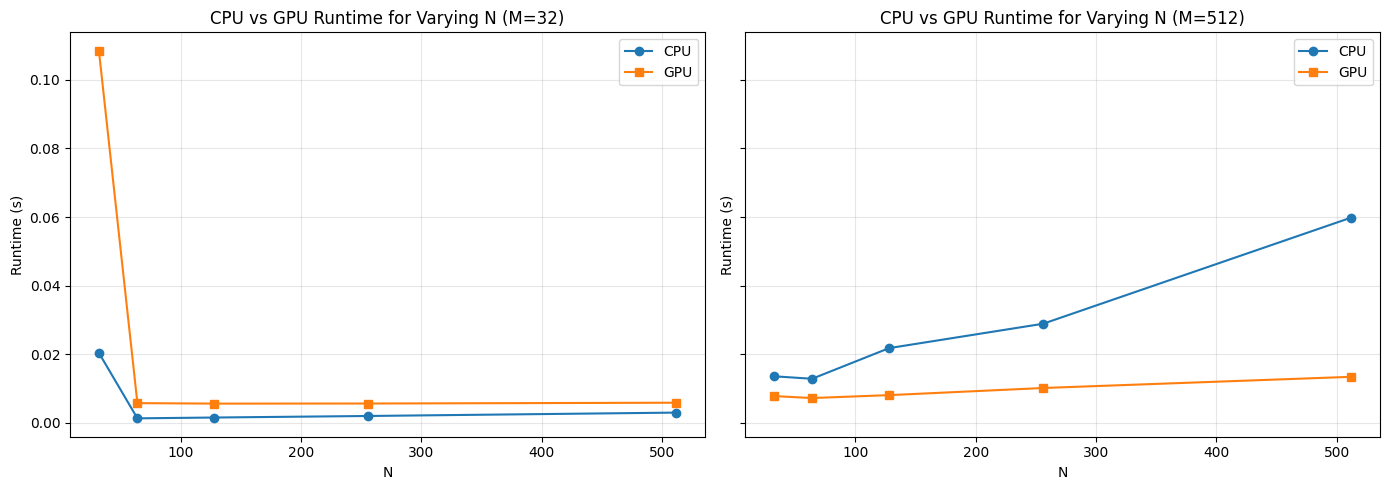

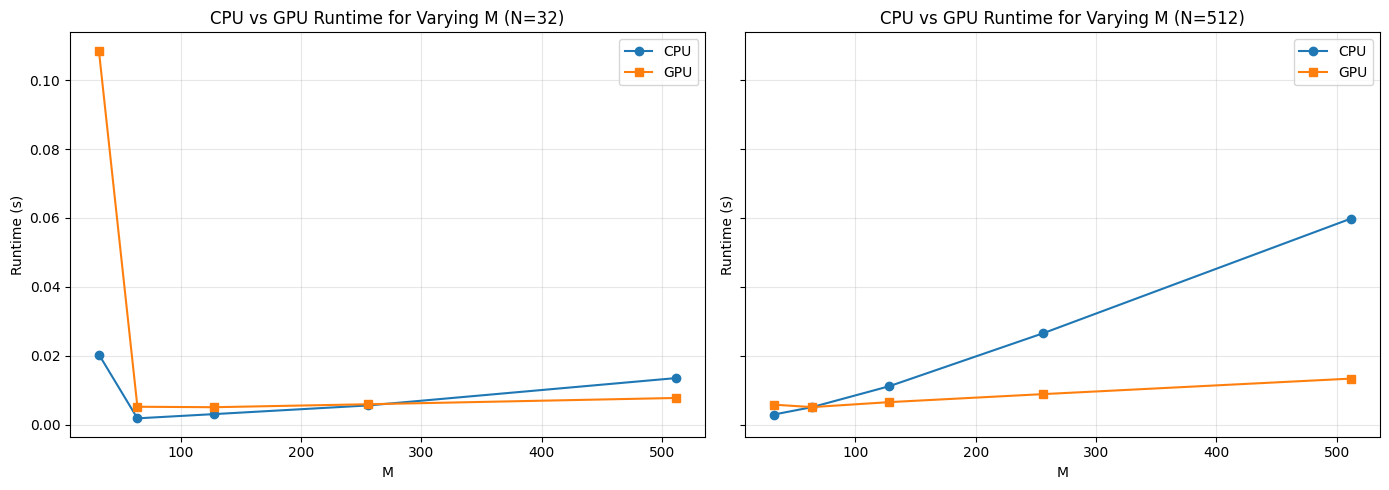

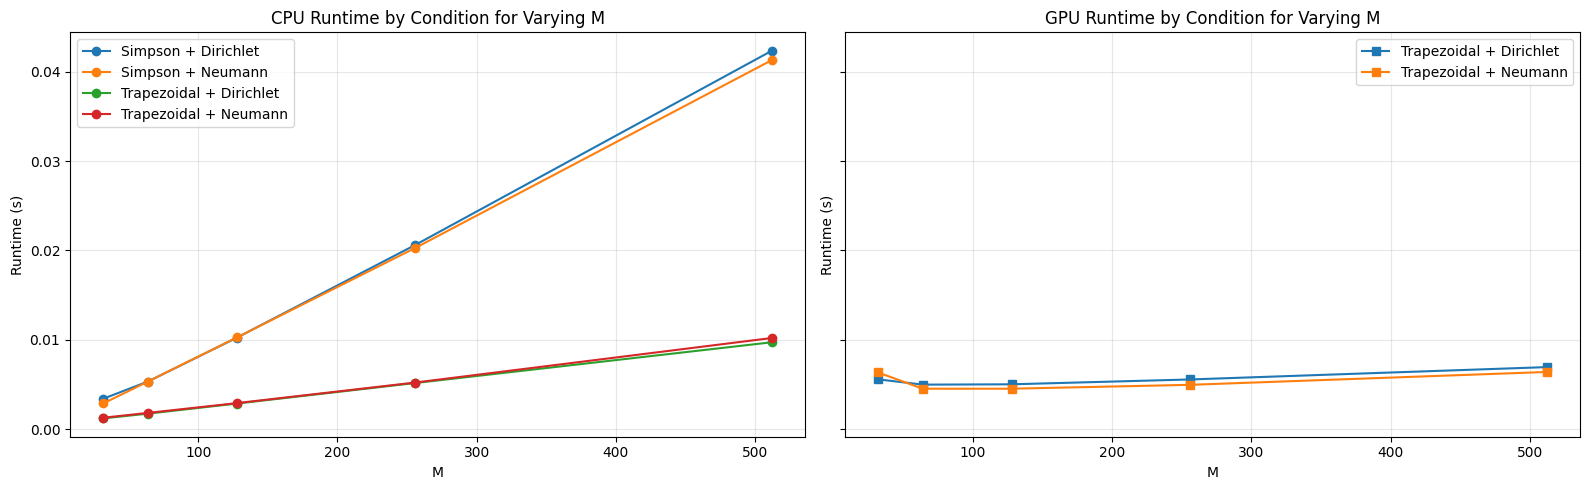

In [7]:
# === Runtime Plots ===

print(f"\n{'='*80}\n Runtime Plots \n{'='*80}")

# 1. Two side-by-side plots: min M vs max M, both varying N
plot_runtime_vs_n(df_nm)

# 2. Two side-by-side plots: min N vs max N, both varying M
plot_runtime_vs_m(df_nm)

# 3. Two side-by-side plots: CPU conditions and GPU conditions, varying M
plot_runtime_conditions_vs_m(df_bc_quad)